In [64]:
import os
os.environ['USE_PYGEOS'] = '0'

import sys
from pathlib import Path
import geopandas as gpd

parent_dir = Path().resolve().parent
sys.path.insert(0, str(os.path.join(parent_dir,'src')))
from utils import *

import matplotlib.pyplot as plt
# import seaborn as sns

In [65]:
gens_gdf = gpd.read_file('../data/osm/plant.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m_update_remove_disconnected.gpkg')

# Import installed capacity of genertors with different energy sources in 2023
# Unit of installed_capacity: GW
df = pd.read_csv('../data/yearly_full_release_long_format.csv')
installed_capacity_df = df[
    (df["Area"] == "Viet Nam") &
    (df["Year"] == 2023) &
    (df["Category"] == "Capacity") &
    (df["Subcategory"] == "Fuel")
]
installed_capacity_df['Value'] = installed_capacity_df['Value'].fillna(0) * 1000 # convert the unit from GW to MW

# Import electricity generation of genertors with different energy sources in 2023
# Unit of electricity_generation: TWh
electricity_generation_df = df[
    (df["Area"] == "Viet Nam") &
    (df["Year"] == 2023) &
    (df["Category"] == "Electricity generation") &
    (df["Subcategory"] == "Fuel") &
    (df["Unit"] == "TWh")
]
electricity_generation_df['Value'] = electricity_generation_df['Value'] * 1000 # convert the unit from TWh to GWh

C:\Users\mye500\AppData\Local\Temp\ipykernel_6688\1885200202.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  installed_capacity_df['Value'] = installed_capacity_df['Value'].fillna(0) * 1000 # convert the unit from GW to MW
C:\Users\mye500\AppData\Local\Temp\ipykernel_6688\1885200202.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  electricity_generation_df['Value'] = electricity_generation_df['Value'] * 1000 # convert the unit from TWh to GWh


In [66]:
electricity_generation_df

,Area,Country code,Year,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
335128,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Bioenergy,TWh,850.0,0.47,123.68
335129,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Coal,TWh,129580.0,25.54,24.55
335130,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Gas,TWh,26320.0,-2.90,-9.92
335131,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Hydro,TWh,80900.0,-15.01,-15.65
335132,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Nuclear,TWh,0.0,0.00,NaN
335133,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Other Fossil,TWh,1720.0,1.00,138.89
335134,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Solar,TWh,25700.0,-0.05,-0.19
335135,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Wind,TWh,11370.0,2.28,25.08


In [67]:
print('Total installed capacity in 2023:', sum(installed_capacity_df['Value']), 'MW')
print('Total electricity generation in 2023:', sum(electricity_generation_df['Value']), 'GWh')

Total installed capacity in 2023: 81380.0 MW
Total electricity generation in 2023: 276440.0 GWh


In [68]:
# Process existing installed capacity and energy source of generators
installed_capacity = []
for i, row in gens_gdf.iterrows():
    try:
        if pd.notnull(row["plant_output_electricity"]):
            installed_capacity.append(convert_to_mw(row["plant_output_electricity"]))
        elif pd.notnull(row["generator_output_electricity"]):
            installed_capacity.append(convert_to_mw(row["generator_output_electricity"]))
        else:
            installed_capacity.append(None)
    except ValueError as e:
        # print("osm_id ", row['osm_id'], ": ", e, " ")
        installed_capacity.append(None)

gens_gdf["installed_capacity"] = installed_capacity

gens_gdf["energy_source"] = gens_gdf["plant_source"].combine_first(gens_gdf["generator_source"])

In [69]:
# Count the unique values in the 'energy_source' column
unique_energy_sources = gens_gdf["energy_source"].dropna().unique()
print("Unique energy sources:", unique_energy_sources)

Unique energy sources: ['coal' 'hydro' 'wind' 'biofuel' 'diesel' 'biogas' 'solar' 'gas' 'gas;oil'
 'oil' 'waste']


In [70]:
# gas_no_capacity = gens_gdf[(gens_gdf['energy_source'] == 'gas')] # & (gens_gdf['installed_capacity'].isna())]
# gas_no_capacity

In [71]:
# 1. Count the number of rows per 'energy_source'
energy_source_counts = gens_gdf.groupby("energy_source").size()

# 2. Count the number of rows per 'energy_source' with and without 'installed_capacity'
installed_capacity_counts = gens_gdf.groupby(["energy_source", ~gens_gdf["installed_capacity"].isna()]).size()

# 3. For rows with 'installed_capacity', calculate the total and average values
installed_capacity_stats = gens_gdf[gens_gdf["installed_capacity"].notna()].groupby("energy_source")["installed_capacity"].agg(['sum', 'mean'])
installed_capacity_stats.rename(columns={'sum': 'Sum installed capacity', 'mean': 'Mean installed capacity'}, inplace=True)

# Output the results
print("Energy source counts (total rows per energy source):")
print(energy_source_counts)

print("\nInstalled capacity counts (rows with and without installed capacity per energy source):")
print(installed_capacity_counts)

print("\nInstalled capacity statistics (sum and mean for rows with installed capacity):")
print(installed_capacity_stats)


Energy source counts (total rows per energy source):
energy_source
biofuel       1
biogas        1
coal         32
diesel        1
gas           7
gas;oil       1
hydro       283
oil           2
solar       328
waste         1
wind       1233
dtype: int64

Installed capacity counts (rows with and without installed capacity per energy source):
energy_source  installed_capacity
biofuel        False                   1
biogas         False                   1
coal           False                   2
               True                   30
diesel         False                   1
gas            False                   1
               True                    6
gas;oil        True                    1
hydro          False                 126
               True                  157
oil            False                   2
solar          False                 283
               True                   45
waste          False                   1
wind           False                 901
      

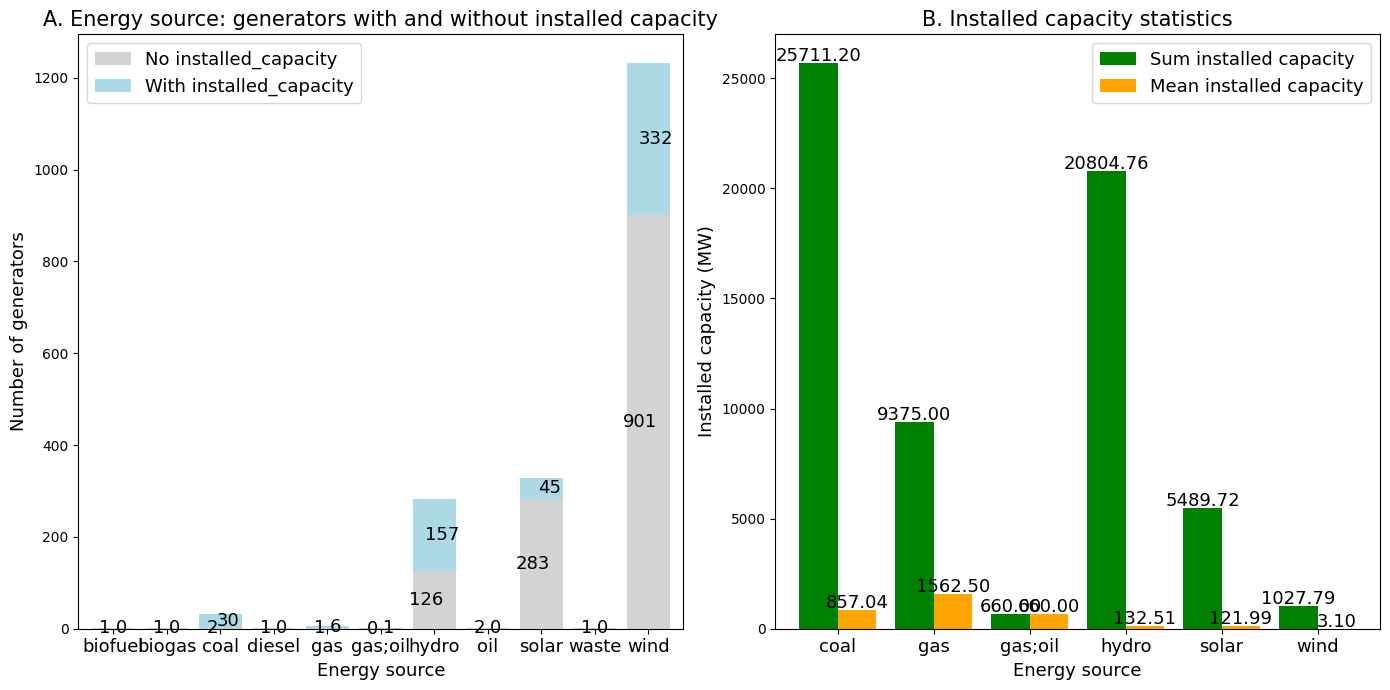

In [72]:
# Display total rows per energy_source and the count of rows with and without 'installed_capacity'
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# (a) Stacked bar chart: Show the number of rows with and without 'installed_capacity' per energy_source
installed_capacity_counts_unstacked = installed_capacity_counts.unstack().fillna(0)
installed_capacity_counts_unstacked.columns = ['No installed_capacity', 'With installed_capacity']
installed_capacity_counts_unstacked.plot(kind='bar', stacked=True, ax=ax[0], width=0.8, color=['lightgray', 'lightblue'])
ax[0].set_title('A. Energy source: generators with and without installed capacity', fontsize=15)
ax[0].set_ylabel('Number of generators', fontsize=13)
ax[0].set_xlabel('Energy source', fontsize=13)
ax[0].legend(fontsize=13)

# Annotate the stacked bar chart with numbers (avoid overlap)
for i, (no_cap, with_cap) in enumerate(zip(installed_capacity_counts_unstacked.iloc[:, 0], installed_capacity_counts_unstacked.iloc[:, 1])):
    if no_cap >= 0:  # 只标记大于 0 的值
        ax[0].annotate(f'{no_cap:.0f}', (i - 0.15, no_cap / 2), ha='center', va='center', fontsize=13, color='black')
    if with_cap >= 0:  # 只标记大于 0 的值
        ax[0].annotate(f'{with_cap:.0f}', (i + 0.15, no_cap + with_cap / 2), ha='center', va='center', fontsize=13, color='black')

# # Annotate the stacked bar chart with numbers
# for p in ax[0].patches:
#     height = p.get_height()
#     x = p.get_x() + p.get_width() / 2.
#     y = p.get_y() + height / 2.

#     ax[0].annotate(f'{height:.0f}', (x, y), ha='center', va='center', fontsize=10, color='black') #, fontweight='bold'

# (b) Display total and mean 'installed_capacity' for each energy_source
installed_capacity_stats.plot(kind='bar', ax=ax[1], width=0.8, color=['green', 'orange'])
ax[1].set_title('B. Installed capacity statistics', fontsize=15)
ax[1].set_ylabel('Installed capacity (MW)', fontsize=13)
ax[1].set_xlabel('Energy source', fontsize=13)
ax[1].legend(fontsize=13)

# Annotate the bar chart with numbers
for p in ax[1].patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2.
    y = height

    ax[1].annotate(f'{height:.2f}', (x, y), ha='center', va='center', fontsize=13, color='black', xytext=(0, 5), textcoords='offset points') #, fontweight='bold'

ax[0].tick_params(axis='x', rotation=0, labelsize=13)
ax[1].tick_params(axis='x', rotation=0, labelsize=13)

plt.tight_layout()
plt.show()


In [73]:
gens_gdf[gens_gdf["energy_source"].isin(["diesel"])]

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,generator_type,substation,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source
23,5246574100,generator,None,None,Trạm cấp xăng An Bình - CA.TPCT,None,None,None,None,None,...,None,None,None,None,None,None,None,POINT (586035.283 1106693.67),NaN,diesel


In [74]:
# Map the energy_source of filtered_gdf
# Create a mapping dictionary to map energy_source to the corresponding INSTALLED CAPACITY (MW)
energy_source_mapping = {
    "hydro": "Hydro",
    "coal": "Coal",
    "oil": "Other Fossil",
    "diesel": "Other Fossil",
    # "oil": "Gas",
    # "diesel": "Gas",
    "gas": "Gas",
    "gas;oil": "Other Fossil",
    # "gas;oil": "Gas",
    "waste": "Other Fossil",
    "biofuel": "Bioenergy", 
    "biogas": "Bioenergy",
    "wind": "Wind",
    "solar": "Solar"
}

# Map the energy_source column to the energy_source_stats column
gens_gdf["energy_source"] = gens_gdf["energy_source"].map(energy_source_mapping)

In [75]:
# Split the GeoDataFrame based on 'energy_source' and 'installed_capacity'
filtered_gdf = gens_gdf.dropna(subset=["energy_source"])
filtered_out_gdf = gens_gdf[~gens_gdf.index.isin(filtered_gdf.index)]

# Further split based on 'installed_capacity' being not null or null
gdf_1 = filtered_gdf[filtered_gdf["installed_capacity"].notnull()]
gdf_2 = filtered_gdf[filtered_gdf["installed_capacity"].isnull()]

# Calculate the total installed_capacity in gdf_1 grouped by energy_source
existing_capacity = gdf_1.groupby("energy_source")["installed_capacity"].sum()

# Output the results
print("Number of original plants/generators: ", len(gens_gdf))
print("Number of plants/generators with energy source: ", len(filtered_gdf))
print(f"Number of rows filtered out: {len(filtered_out_gdf)}")
print("---------------")

print(f"GeoDataFrame 1 (not null energy_source and installed_capacity): {len(gdf_1)} rows")
print(f"GeoDataFrame 2 (not null energy_source but null installed_capacity): {len(gdf_2)} rows")

Number of original plants/generators:  1903
Number of plants/generators with energy source:  1890
Number of rows filtered out: 13
---------------
GeoDataFrame 1 (not null energy_source and installed_capacity): 571 rows
GeoDataFrame 2 (not null energy_source but null installed_capacity): 1319 rows


Note: In filtered_out_gdf (energy_source is None), there is only one plant has installed_capacity 49.3 MW.

In [76]:
# df = pd.read_csv('../data/yearly_full_release_long_format.csv')

# # Filter data: only include data for "Viet Nam", "Capacity", and "Fuel" categories
# installed_capacity_df = df[
#     (df["Area"] == "Viet Nam") &
#     (df["Category"] == "Capacity") &
#     (df["Subcategory"] == "Fuel")
# ]

# # Select necessary columns
# data = installed_capacity_df[['Year', 'Variable', 'Value', 'YoY % change']]

# # Exclude 'Nuclear' and 'Other Fossil'
# data = data[~data['Variable'].isin(['Nuclear', 'Other Fossil'])]

# # Calculate the average annual growth rate for recent years and predict the value for 2024 based on this average
# def predict_for_variable_using_growth_rate(variable_df):
#     # Filter out rows with NaN values (if any)
#     variable_df = variable_df.dropna(subset=['Value', 'YoY % change'])
    
#     # If there are not enough data points to make a prediction, return NaN
#     if len(variable_df) < 2:
#         return np.nan
    
#     # Calculate the average growth rate for recent years (e.g., the last 3 years)
#     recent_years = variable_df.tail(3)  # Take the last three years of data
#     avg_growth_rate = recent_years['YoY % change'].mean()  # Calculate the average

#     # Take the Value for 2023
#     value_2023 = recent_years.iloc[-1]['Value']

#     # Predict the value for 2024 based on the average growth rate
#     predicted_value_2024 = value_2023 * (1 + avg_growth_rate / 100)
    
#     return predicted_value_2024

# # Get the predicted values for each energy type
# predictions = []
# for variable in data['Variable'].unique():
#     variable_data = data[data['Variable'] == variable]
#     predicted_value_2024 = predict_for_variable_using_growth_rate(variable_data)
    
#     # Collect the prediction results
#     predictions.append({
#         'Variable': variable,
#         'Predicted_Value_2024': predicted_value_2024
#     })

# # Convert the results to a DataFrame
# predictions_df = pd.DataFrame(predictions)

In [77]:
installed_capacity_df

,Area,Country code,Year,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
335098,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Capacity,Fuel,Bioenergy,GW,380.0,0.00,0.00
335099,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Capacity,Fuel,Coal,GW,27240.0,2.63,10.69
335100,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Capacity,Fuel,Gas,GW,8150.0,0.00,0.00
335101,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Capacity,Fuel,Hydro,GW,22640.0,0.11,0.49
335102,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Capacity,Fuel,Nuclear,GW,0.0,NaN,NaN
335103,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Capacity,Fuel,Other Fossil,GW,0.0,NaN,NaN
335104,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Capacity,Fuel,Solar,GW,17080.0,0.38,2.28
335105,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Capacity,Fuel,Wind,GW,5890.0,0.82,16.17


In [78]:
existing_capacity

energy_source
Coal            25711.200
Gas              9375.000
Hydro           20804.758
Other Fossil      660.000
Solar            5489.722
Wind             1027.793
Name: installed_capacity, dtype: float64

In [79]:
# Subtract the grouped installed_capacity values of gdf_1 from energy_source_stats
remaining_capacity = {}
for _, row in installed_capacity_df.iterrows():
    category = row["Variable"]
    if category in existing_capacity:
        remaining_capacity[category] = row['Value'] - existing_capacity[category]
    else:
        remaining_capacity[category] = row['Value']

remaining_capacity

{'Bioenergy': 380.0,
 'Coal': 1528.7999999999993,
 'Gas': -1225.0,
 'Hydro': 1835.2419999999984,
 'Nuclear': 0.0,
 'Other Fossil': -660.0,
 'Solar': 11590.278,
 'Wind': 4862.207}

In [80]:
sum(gdf_1['installed_capacity'])

63068.47299999999

In [81]:
# Allocate the remaining capacity equally to gdf_2 
# Calculate the number of rows for each energy_source in gdf_2
gdf_2_counts = gdf_2["energy_source"].value_counts()
print('The number of rows with NULL capacity by energy source: ',gdf_2_counts)

# Create a new column to allocate the remaining capacity to each row in gdf_2
gdf_2["installed_capacity"] = gdf_2["energy_source"].map(remaining_capacity) / gdf_2["energy_source"].map(gdf_2_counts)

# Replace NaN values with 0 if any energy_source doesn't have a remaining_capacity or count
gdf_2["installed_capacity"] = gdf_2["installed_capacity"].fillna(0)

# Set installed_capacity to 0 if the corresponding remaining_capacity is less than 0
gdf_2["installed_capacity"] = gdf_2["installed_capacity"].where(gdf_2["energy_source"].map(remaining_capacity) >= 0, 0)

gdf_2.head()

The number of rows with NULL capacity by energy source:  energy_source
Wind            901
Solar           283
Hydro           126
Other Fossil      4
Coal              2
Bioenergy         2
Gas               1
Name: count, dtype: int64


c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,generator_type,substation,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source
0,2495831951,generator,None,None,Nhà máy nhiệt điện HẢi Phòng,None,None,None,None,yes,...,francis_turbine,None,None,None,None,None,None,POINT (672042.829 2306269.564),764.400000,Coal
22,5207569281,generator,None,None,Trạm biến áp 110/220v,None,None,None,None,None,...,None,None,None,None,None,None,None,POINT (584157.03 1108307.081),190.000000,Bioenergy
23,5246574100,generator,None,None,Trạm cấp xăng An Bình - CA.TPCT,None,None,None,None,None,...,None,None,None,None,None,None,None,POINT (586035.283 1106693.67),0.000000,Other Fossil
24,5246576900,generator,None,None,Tram xang dau QL1,None,None,None,None,None,...,None,None,None,None,None,None,None,POINT (582155.543 1105082.909),190.000000,Bioenergy
25,5573888849,generator,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,POINT (929588.345 1168437.423),5.396456,Wind


In [82]:
gens_gdf_update = pd.concat([gdf_1, gdf_2], ignore_index=True)

In [83]:
len(gens_gdf_update)

1890

In [84]:
gens_gdf_update.head()

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,generator_type,substation,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source
0,4037744488,plant,None,None,Nhà máy thủy điện Ialy,None,720 MW,hydro,None,None,...,None,None,None,None,None,None,None,POINT (801696.934 1574168.128),720.0,Hydro
1,4195284426,generator,None,None,None,None,None,None,None,1500 kW,...,horizontal_axis,None,None,None,None,None,None,POINT (902041.116 1240835.743),1.5,Wind
2,4195284427,generator,None,None,None,None,None,None,None,1500 kW,...,horizontal_axis,None,None,None,None,None,None,POINT (901941.698 1241043.24),1.5,Wind
3,4195284428,generator,None,None,None,None,None,None,None,1500 kW,...,horizontal_axis,None,None,None,None,None,None,POINT (902908.591 1241107.802),1.5,Wind
4,4195284429,generator,None,None,None,None,None,None,None,1500 kW,...,horizontal_axis,None,None,None,None,None,None,POINT (901839.356 1241250.103),1.5,Wind


In [85]:
electricity_generation_df.head()

,Area,Country code,Year,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
335128,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Bioenergy,TWh,850.0,0.47,123.68
335129,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Coal,TWh,129580.0,25.54,24.55
335130,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Gas,TWh,26320.0,-2.90,-9.92
335131,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Hydro,TWh,80900.0,-15.01,-15.65
335132,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Nuclear,TWh,0.0,0.00,NaN


In [86]:
# Distribute electricity generation (attribute: Value) based on installed capacity and grouped by energy_source
def distribute_generation_by_capacity(row):
    # Filter electricity_generation_df based on the generator's energy source (attribur: Variable)
    electricity_generation = electricity_generation_df[electricity_generation_df['Variable'] == row['energy_source']]
    
    if not electricity_generation.empty:
        # Get total installed capacity for this energy source
        total_capacity = gens_gdf_update.loc[gens_gdf_update['energy_source'] == row['energy_source'], 'installed_capacity'].sum()
        
        # Avoid division by zero
        if total_capacity > 0:
            proportion = row['installed_capacity'] / total_capacity
            return electricity_generation['Value'].values[0] * proportion
        else:
            return 0  # No installed capacity for this energy source, so no generation assigned
    else:
        return 0  # No generation data available for this energy source

# Apply the new distribution function
gens_gdf_update['electricity_generation_GWh'] = gens_gdf_update.apply(distribute_generation_by_capacity, axis=1)

In [87]:
gens_gdf_update.head()

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,substation,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source,electricity_generation_GWh
0,4037744488,plant,None,None,Nhà máy thủy điện Ialy,None,720 MW,hydro,None,None,...,None,None,None,None,None,None,POINT (801696.934 1574168.128),720.0,Hydro,2572.791519
1,4195284426,generator,None,None,None,None,None,None,None,1500 kW,...,None,None,None,None,None,None,POINT (902041.116 1240835.743),1.5,Wind,2.895586
2,4195284427,generator,None,None,None,None,None,None,None,1500 kW,...,None,None,None,None,None,None,POINT (901941.698 1241043.24),1.5,Wind,2.895586
3,4195284428,generator,None,None,None,None,None,None,None,1500 kW,...,None,None,None,None,None,None,POINT (902908.591 1241107.802),1.5,Wind,2.895586
4,4195284429,generator,None,None,None,None,None,None,None,1500 kW,...,None,None,None,None,None,None,POINT (901839.356 1241250.103),1.5,Wind,2.895586


In [88]:
sum(gens_gdf_update['electricity_generation_GWh'])

276439.99999998545

In [89]:
gens_gdf_update.loc[gens_gdf_update['energy_source'] == 'Gas', 'installed_capacity'].sum()

9375.0

In [90]:
# # Assign electricity generation
# # Step 1: Calculate Area for each generator
# def calculate_area(geometry):
#     geometry = linestring_to_polygon(geometry)
    
#     if geometry.geom_type in ['Polygon', 'MultiPolygon', 'LineString']:
#         return geometry.area
#     elif geometry.geom_type == 'Point':
#         return 500  # Default area for Point
#     else:
#         return 0

# # Apply the area calculation to each generator
# gens_gdf_update['Area'] = gens_gdf_update['geometry'].apply(calculate_area)

# # Step 2: Distribute Value_GWh based on Area and energy_source
# def distribute_generation(row):
#     # Filter electricity_generation_df based on the current generator's energy source
#     relevant_generation = electricity_generation_df[electricity_generation_df['Variable'] == row['energy_source']]
#     if not relevant_generation.empty:
#         total_area = gens_gdf_update.loc[gens_gdf_update['energy_source'] == row['energy_source'], 'Area'].sum()
#         proportion = row['Area'] / total_area
#         return relevant_generation['Value_GWh'].values[0] * proportion
#     else:
#         return 0

# # Apply the distribution function to each generator
# gens_gdf_update['electricity_generation_GWh'] = gens_gdf_update.apply(distribute_generation, axis=1)

# gens_gdf_update

In [91]:
gens_gdf_update[gens_gdf_update['osm_id'] == '1163917627']

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,substation,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source,electricity_generation_GWh
1774,1163917627,generator,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,"LINESTRING (665328.452 1175112.075, 665326.963...",40.955046,Solar,61.624396


# Connect generators to corresponding buses

In [92]:
distance_threshold = 570000  # 570 km

for idx, generator in gens_gdf_update.iterrows():
    distances = nodes_gdf.geometry.distance(generator.geometry)

    # Find the nearest node and ensure its distance is within the threshold
    nearest_idx = distances.idxmin()  # Find the index of the minimum distance
    nearest_distance = distances.loc[nearest_idx]

    if nearest_distance <= distance_threshold:
        nearest_node_id = nodes_gdf.at[nearest_idx, 'NodeID']
        # Assign the NodeID of the nearest node to the generator's BusID
        gens_gdf_update.at[idx, 'BusID'] = nearest_node_id
    else:
        # If no node meets the condition, set BusID to None or another default value
        gens_gdf_update.at[idx, 'BusID'] = None

# Check if there are any rows with BusID as None
none_busid_count = gens_gdf_update['BusID'].isna().sum()
print(f"Number of generators with BusID as None: {none_busid_count}")

Number of generators with BusID as None: 0


In [93]:
gens_gdf_update.set_crs('EPSG:32648', inplace=True)
gens_gdf_update.to_file("../outputs/plant_update.gpkg", driver="GPKG")
gens_gdf_update.to_excel("../outputs/plant_update.xlsx", index=False)

In [63]:
gens_gdf_update.head()

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source,electricity_generation_GWh,BusID
0,4037744488,plant,None,None,Nhà máy thủy điện Ialy,None,720 MW,hydro,None,None,...,None,None,None,None,None,POINT (801696.934 1574168.128),720.0,Hydro,2572.791519,NODEVN3320
1,4195284426,generator,None,None,None,None,None,None,None,1500 kW,...,None,None,None,None,None,POINT (902041.116 1240835.743),1.5,Wind,2.895586,NODEVN3961
2,4195284427,generator,None,None,None,None,None,None,None,1500 kW,...,None,None,None,None,None,POINT (901941.698 1241043.24),1.5,Wind,2.895586,NODEVN3961
3,4195284428,generator,None,None,None,None,None,None,None,1500 kW,...,None,None,None,None,None,POINT (902908.591 1241107.802),1.5,Wind,2.895586,NODEVN3960
4,4195284429,generator,None,None,None,None,None,None,None,1500 kW,...,None,None,None,None,None,POINT (901839.356 1241250.103),1.5,Wind,2.895586,NODEVN3961
